In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
base_path = r"C:\Users\saura\Downloads\archive\real_vs_fake\real-vs-fake"

train_dir = base_path + r"\train"
val_dir   = base_path + r"\valid"
test_dir  = base_path + r"\test"

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [4]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 25000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
print(train_data.class_indices)

{'fake': 0, 'real': 1}


In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 593s 751ms/step - accuracy: 0.7052 - loss: 0.5695 - val_accuracy: 0.7600 - val_loss: 0.4882
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 604s 773ms/step - accuracy: 0.7499 - loss: 0.5157 - val_accuracy: 0.7660 - val_loss: 0.4889
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 557s 712ms/step - accuracy: 0.7571 - loss: 0.5005 - val_accuracy: 0.7858 - val_loss: 0.4556
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 605s 774ms/step - accuracy: 0.7641 - loss: 0.4872 - val_accuracy: 0.7840 - val_loss: 0.4543
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 638s 816ms/step - accuracy: 0.7688 - loss: 0.4807 - val_accuracy: 0.7996 - val_loss: 0.4395


In [10]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 605s 773ms/step - accuracy: 0.7741 - loss: 0.4774 - val_accuracy: 0.7954 - val_loss: 0.4377
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 610s 779ms/step - accuracy: 0.7773 - loss: 0.4691 - val_accuracy: 0.7958 - val_loss: 0.4340
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 604s 772ms/step - accuracy: 0.7860 - loss: 0.4574 - val_accuracy: 0.8038 - val_loss: 0.4245
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 605s 774ms/step - accuracy: 0.7858 - loss: 0.4550 - val_accuracy: 0.7976 - val_loss: 0.4345
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 607s 776ms/step - accuracy: 0.7851 - loss: 0.4543 - val_accuracy: 0.8046 - val_loss: 0.4156


In [12]:
for layer in base_model.layers[-80:]:
    layer.trainable = True

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),   
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 890s 1s/step - accuracy: 0.7856 - loss: 0.4671 - val_accuracy: 0.7056 - val_loss: 0.8738
Epoch 2/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 862s 1s/step - accuracy: 0.8863 - loss: 0.2809 - val_accuracy: 0.8872 - val_loss: 0.2796
Epoch 3/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 862s 1s/step - accuracy: 0.9216 - loss: 0.1991 - val_accuracy: 0.9404 - val_loss: 0.1541
Epoch 4/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 883s 1s/step - accuracy: 0.9396 - loss: 0.1604 - val_accuracy: 0.9440 - val_loss: 0.1522
Epoch 5/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 877s 1s/step - accuracy: 0.9496 - loss: 0.1335 - val_accuracy: 0.9084 - val_loss: 0.2520
Epoch 6/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 876s 1s/step - accuracy: 0.9578 - loss: 0.1100 - val_accuracy: 0.9154 - val_loss: 0.2291
Epoch 7/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 872s 1s/step - accuracy: 0.9650 - loss: 0.0991 - val_accuracy: 0.9546 - val_loss: 0.1216
Epoch 8/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 869s 1s/step - accuracy: 0.9697 - loss: 0.0835 - val_accuracy: 0.

In [15]:
loss, acc = model.evaluate(test_data)
print("Final Test Accuracy:", acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 323ms/step - accuracy: 0.9608 - loss: 0.1021
Final Test Accuracy: 0.9607999920845032


In [19]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis('off')

    if pred > 0.5:
        print("REAL")
    else:
        print("FAKE")

    print("Confidence:", float(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
REAL
Confidence: 0.9996901750564575


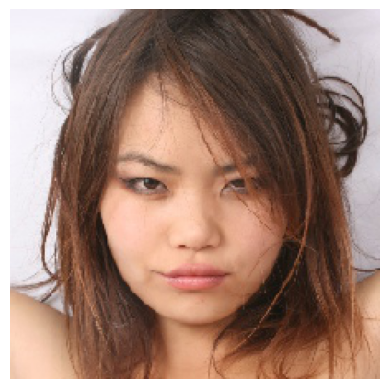

In [22]:
predict_image(r"C:\Users\saura\Downloads\archive\real_vs_fake\real-vs-fake\test\real\45909.jpg")

In [23]:
model.save("deepfake_model.h5")

157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 346ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2500
           1       0.94      0.98      0.96      2500

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000


Confusion Matrix:
 [[2356  144]
 [  52 2448]]


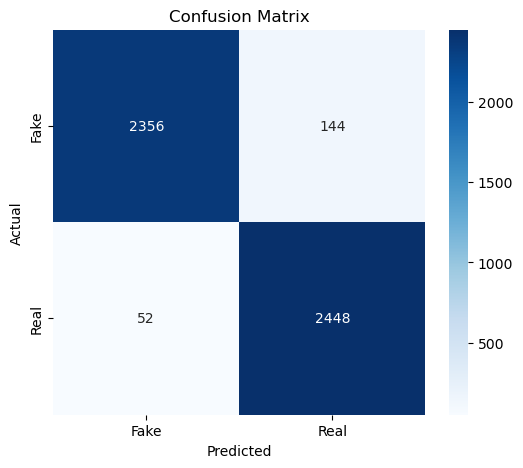

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Predictions on test data
y_pred = model.predict(test_data)

# Step 2: Convert probabilities → 0/1
y_pred = (y_pred > 0.5).astype(int)

# Step 3: True labels
y_true = test_data.classes

# Step 4: Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

# Step 5: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n", cm)

# Step 6: Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [6]:
model = tf.keras.models.load_model("deepfake_model.h5")

In [7]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis('off')

    if pred > 0.5:
        print("REAL")
    else:
        print("FAKE")

    print("Confidence:", float(pred))
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
REAL
Confidence: 0.9999932646751404


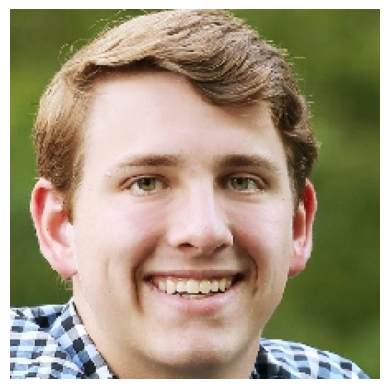

In [9]:
predict_image(r"C:\Users\saura\Downloads\archive\real_vs_fake\real-vs-fake\test\real\45997.jpg")

In [13]:
model.save("deepfake_model.keras")